## Visualizes BayesWave reconstruction results across multiple experiments

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
#from gwpy.timeseries import TimeSeries
#from gwpy.frequencyseries import FrequencySerie
import seaborn as sns
sns.set(style='whitegrid', context='paper', font_scale=1.8)

In [ ]:
def load_time_domain_data(filepath):
    """Load time domain data from BayesWave output files.
    
    Parameters
    ----------
    filepath : str or Path
        Path to the data file
    
    Returns
    -------
    np.ndarray
        Array with shape (N, 2) containing [time, strain] columns
    """
    with open(filepath, 'r') as f:
        for line in f:
            if line.strip() == '---------------':
                break
        next(f)
        data = []
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                data.append([float(parts[0]), float(parts[1])])
    
    return np.array(data)


def load_psd_data(filepath):
    """Load power spectral density data from BayesWave output files.
    
    Parameters
    ----------
    filepath : str or Path
        Path to the PSD data file
    
    Returns
    -------
    np.ndarray
        Array with shape (N, 2) containing [frequency, PSD] columns
    """
    with open(filepath, 'r') as f:
        for line in f:
            if line.strip() == '---------------':
                break
        next(f)
        data = []
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                data.append([float(parts[0]), float(parts[1])])
    
    return np.array(data)

In [ ]:
# Experiment parameters
durations = ['04s', '08s', '16s', '32s']
amplitudes = ['1.25', '2.50', '5.00']
base_path = Path('/anvil/scratch/x-ctirapongpra/gw-collapsar/Frames')

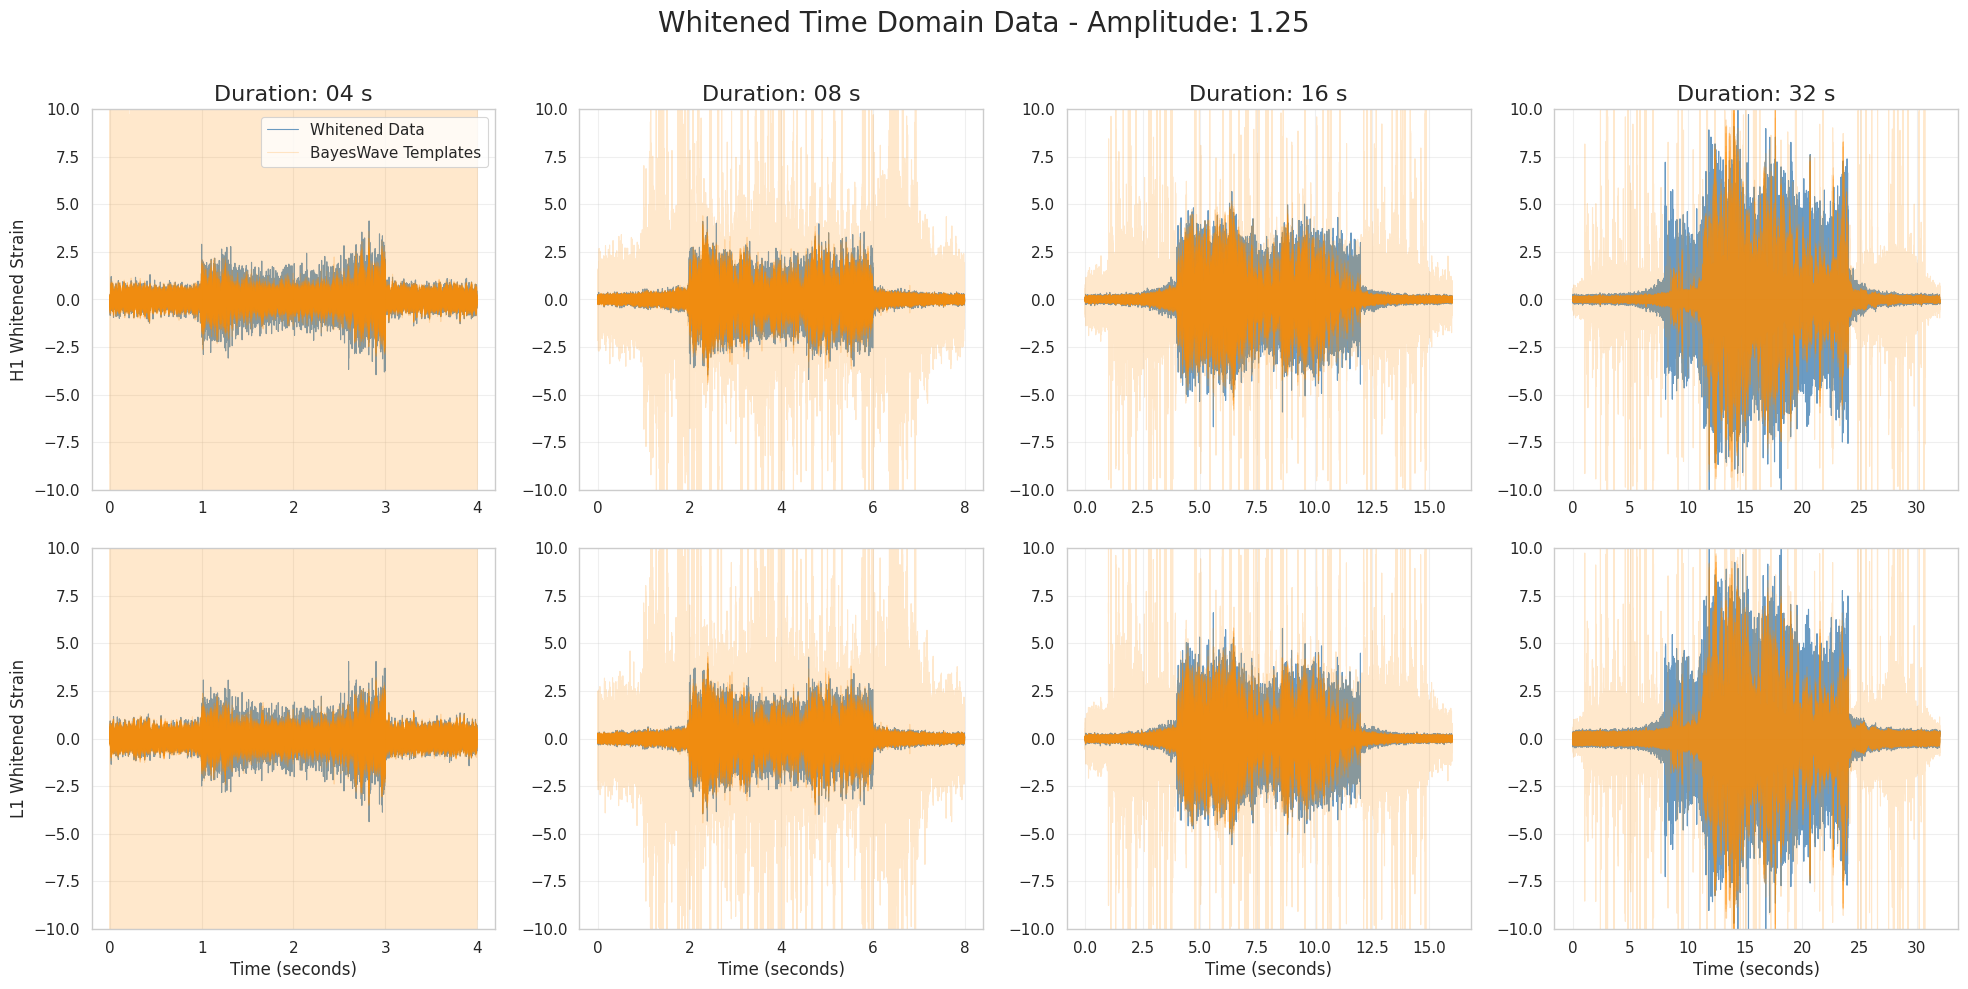

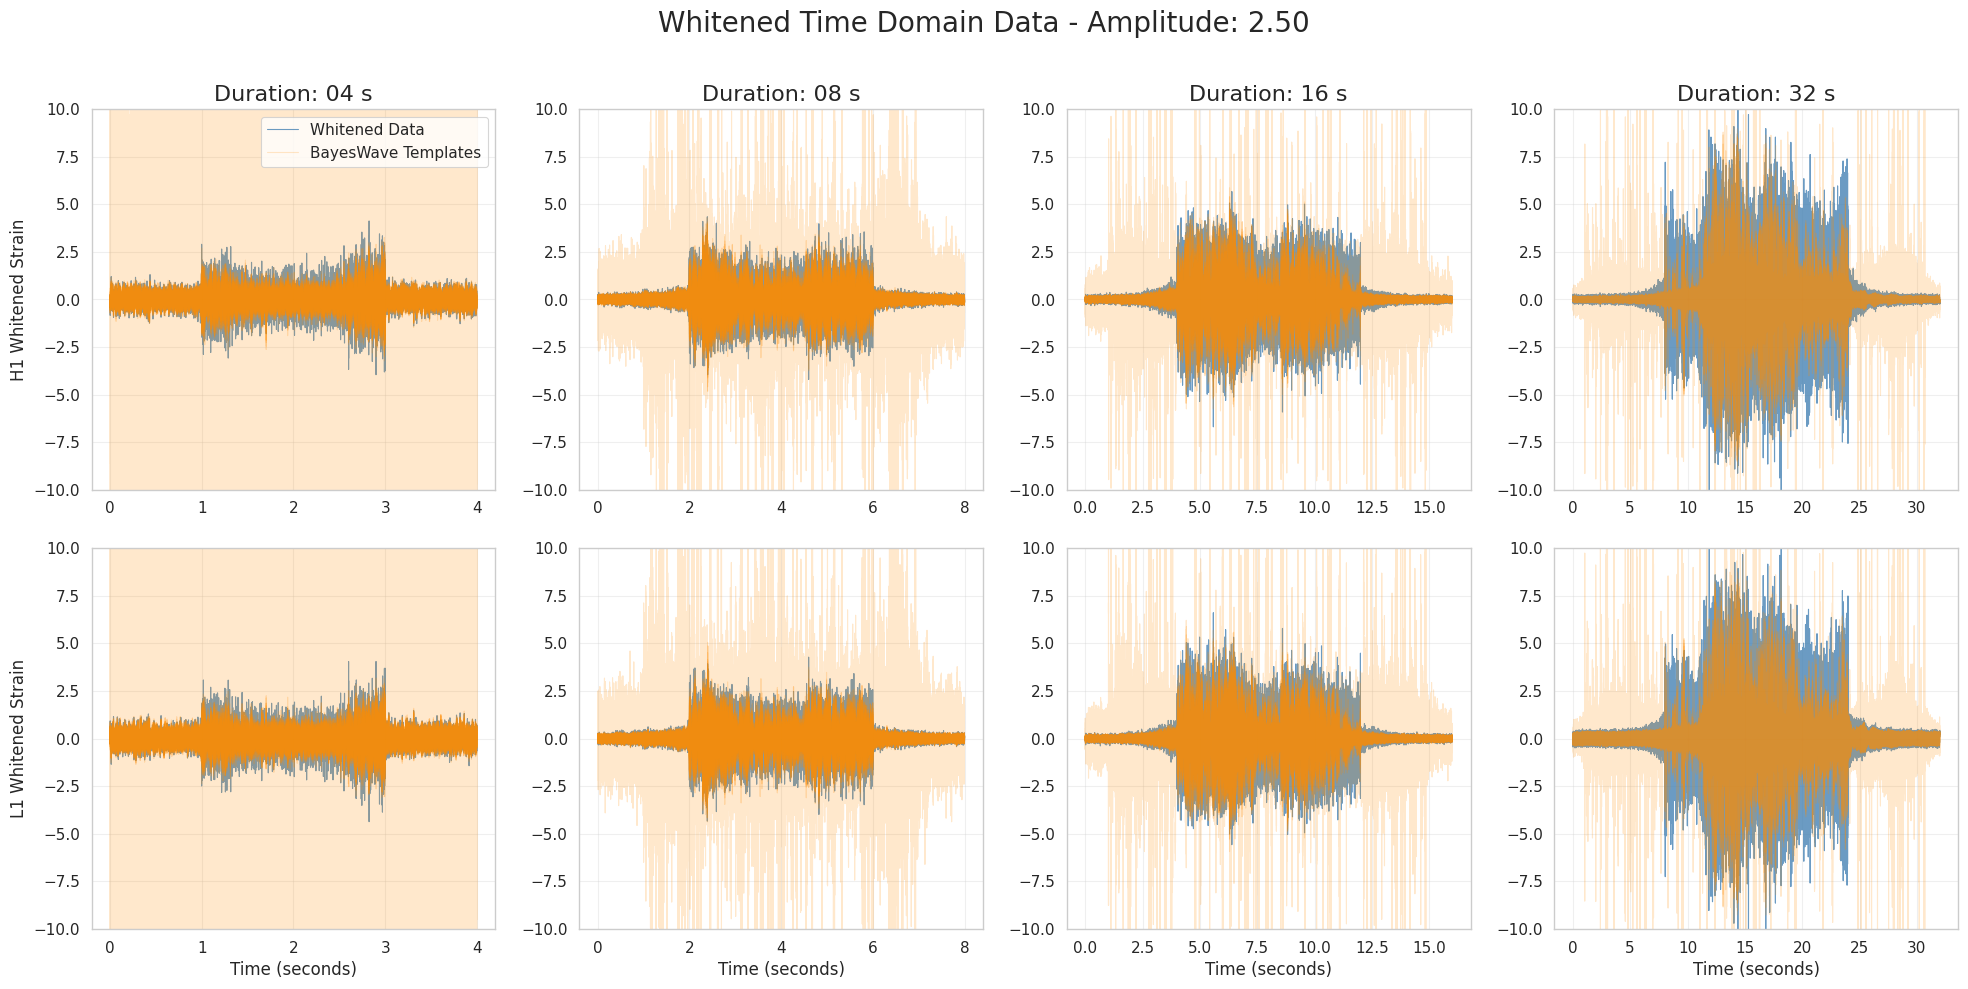

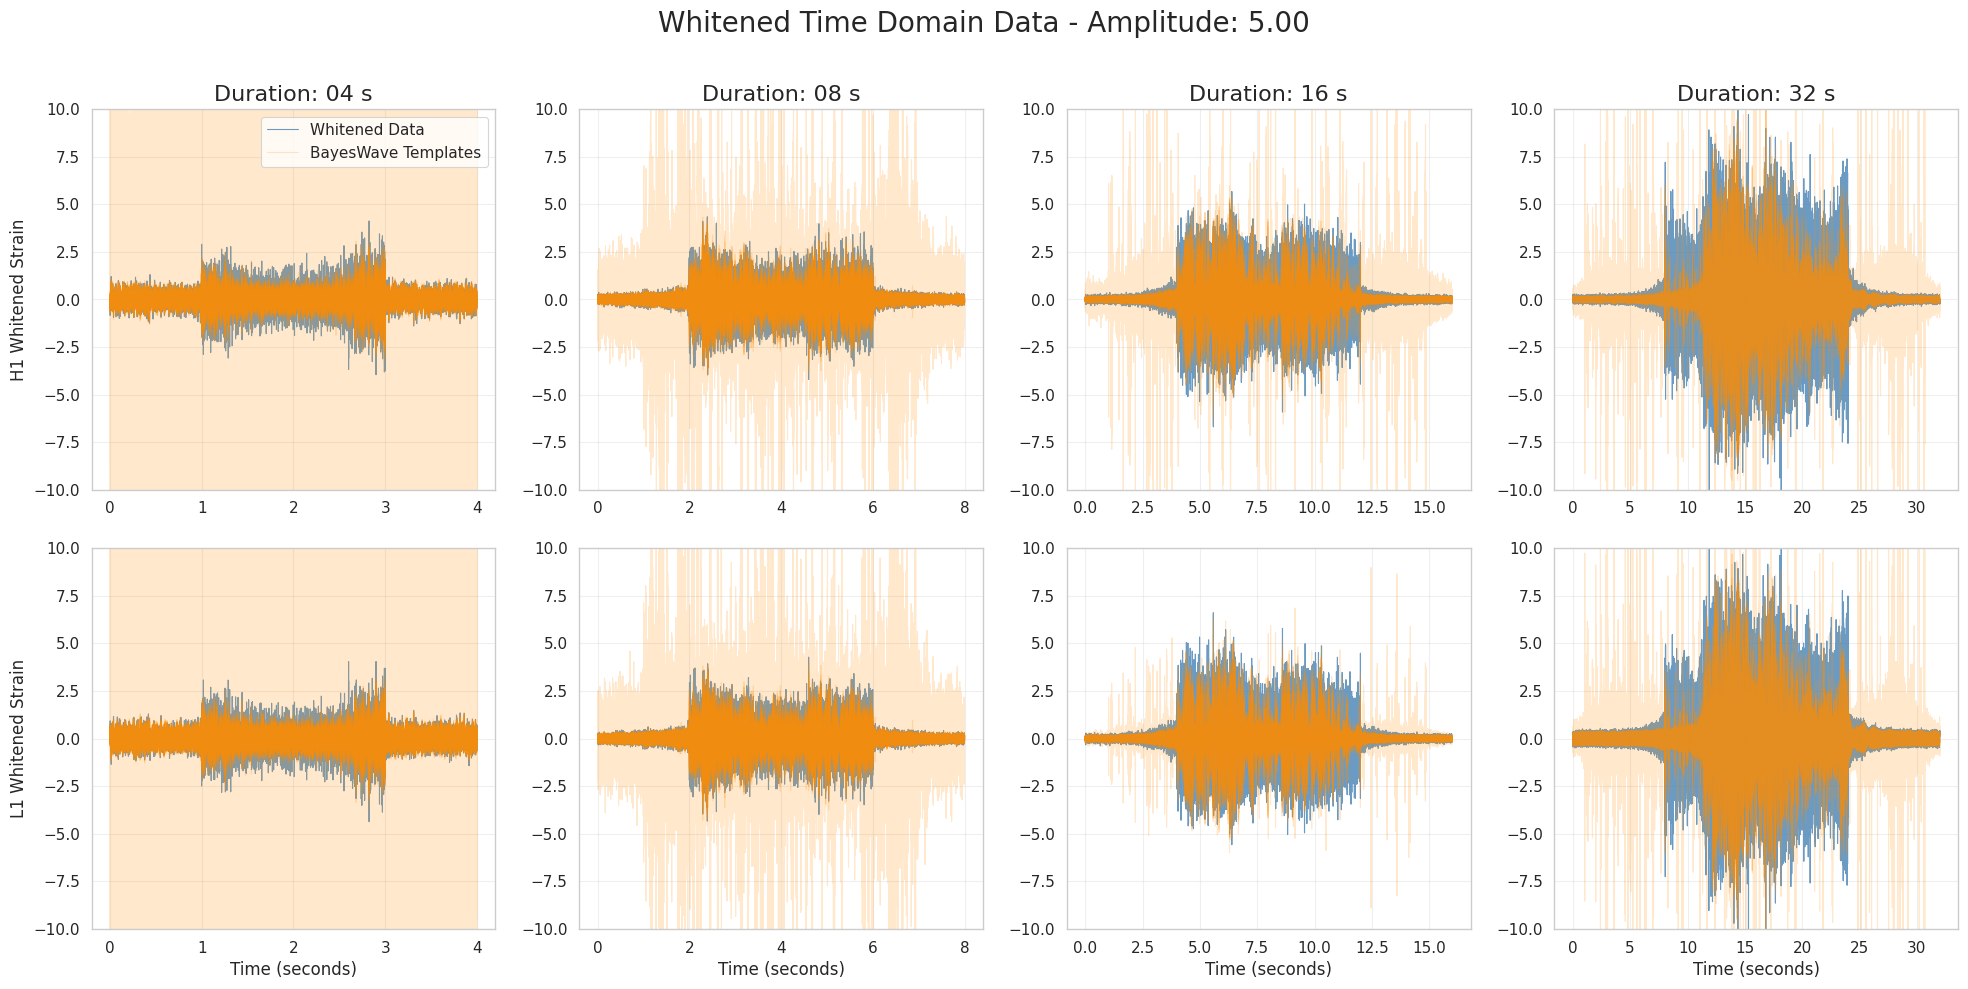

In [ ]:
# Plot whitened data: BayesWave reconstruction vs real strain
for amp in amplitudes:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    for col_idx, dur in enumerate(durations):
        exp_dir = base_path / f'dur_{dur}_amp_{amp}'
        data_dir = exp_dir / 'bayeswave_output_0' / 'data'
        template_dir = exp_dir / 'bayeswave_output_0' / 'templates'
        
        # Load whitened data
        h1_whitened = load_time_domain_data(data_dir / 'whitened_time_domain_data_H1.dat')
        l1_whitened = load_time_domain_data(data_dir / 'whitened_time_domain_data_L1.dat')
        
        # Plot H1
        ax_h1 = axes[0, col_idx]
        ax_h1.plot(h1_whitened[:, 0], h1_whitened[:, 1], '-', 
                   color='steelblue', linewidth=0.8, label='Whitened Data', alpha=0.8)
        
        # Plot all 11 whitened BayesWave templates with low alpha
        for i in range(11):
            template_file = template_dir / f'all_whitened_time_domain_template_H1_{i}.dat'
            if template_file.exists():
                h1_template = load_time_domain_data(template_file)
                
                label = 'BayesWave Templates' if i == 0 else None
                ax_h1.plot(h1_template[:, 0], h1_template[:, 1], '-', 
                           color='darkorange', linewidth=0.8, label=label, alpha=0.2)
        
        ax_h1.set_title(f'Duration: {dur.replace("s", " s")}', fontsize=16)
        if col_idx == 0:
            ax_h1.set_ylabel('H1 Whitened Strain', fontsize=12)
            ax_h1.legend(loc='upper right', fontsize=11)
        ax_h1.grid(True, alpha=0.3)
        ax_h1.tick_params(axis='both', which='major', labelsize=11)
        ax_h1.set_ylim(-10, 10)
        
        # Plot L1
        ax_l1 = axes[1, col_idx]
        ax_l1.plot(l1_whitened[:, 0], l1_whitened[:, 1], '-', 
                   color='steelblue', linewidth=0.8, label='Whitened Data', alpha=0.8)
        
        # Plot all 11 whitened BayesWave templates with low alpha
        for i in range(11):
            template_file = template_dir / f'gw_all_whitened_time_domain_template_L1_{i}.dat'
            if template_file.exists():
                l1_template = load_time_domain_data(template_file)
                
                label = 'BayesWave Templates' if i == 0 else None
                ax_l1.plot(l1_template[:, 0], l1_template[:, 1], '-', 
                           color='darkorange', linewidth=0.8, label=label, alpha=0.2)
        
        if col_idx == 0:
            ax_l1.set_ylabel('L1 Whitened Strain', fontsize=12)
        ax_l1.set_xlabel('Time (seconds)', fontsize=12)
        ax_l1.grid(True, alpha=0.3)
        ax_l1.tick_params(axis='both', which='major', labelsize=11)
        ax_l1.set_ylim(-10, 10)
    fig.suptitle(f'Whitened Time Domain Data - Amplitude: {amp}', fontsize=20, y=0.995)
    plt.tight_layout()
    plt.show()

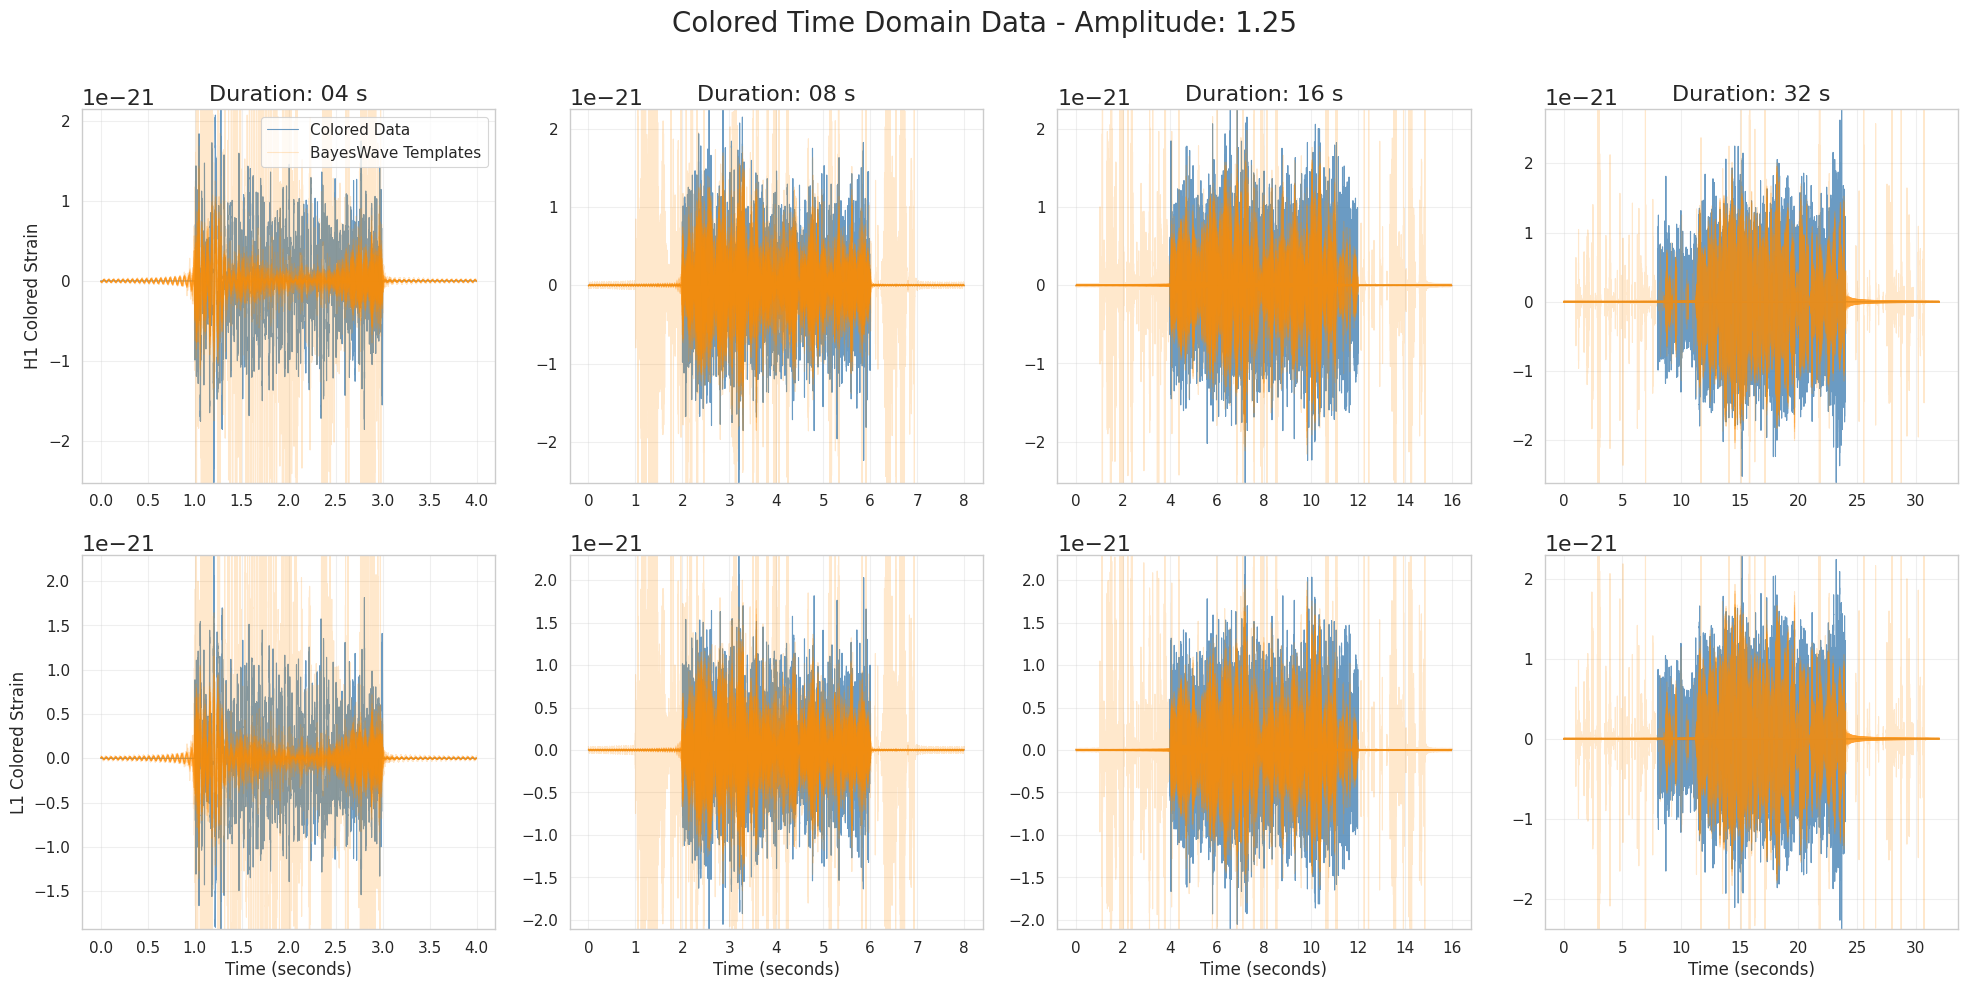

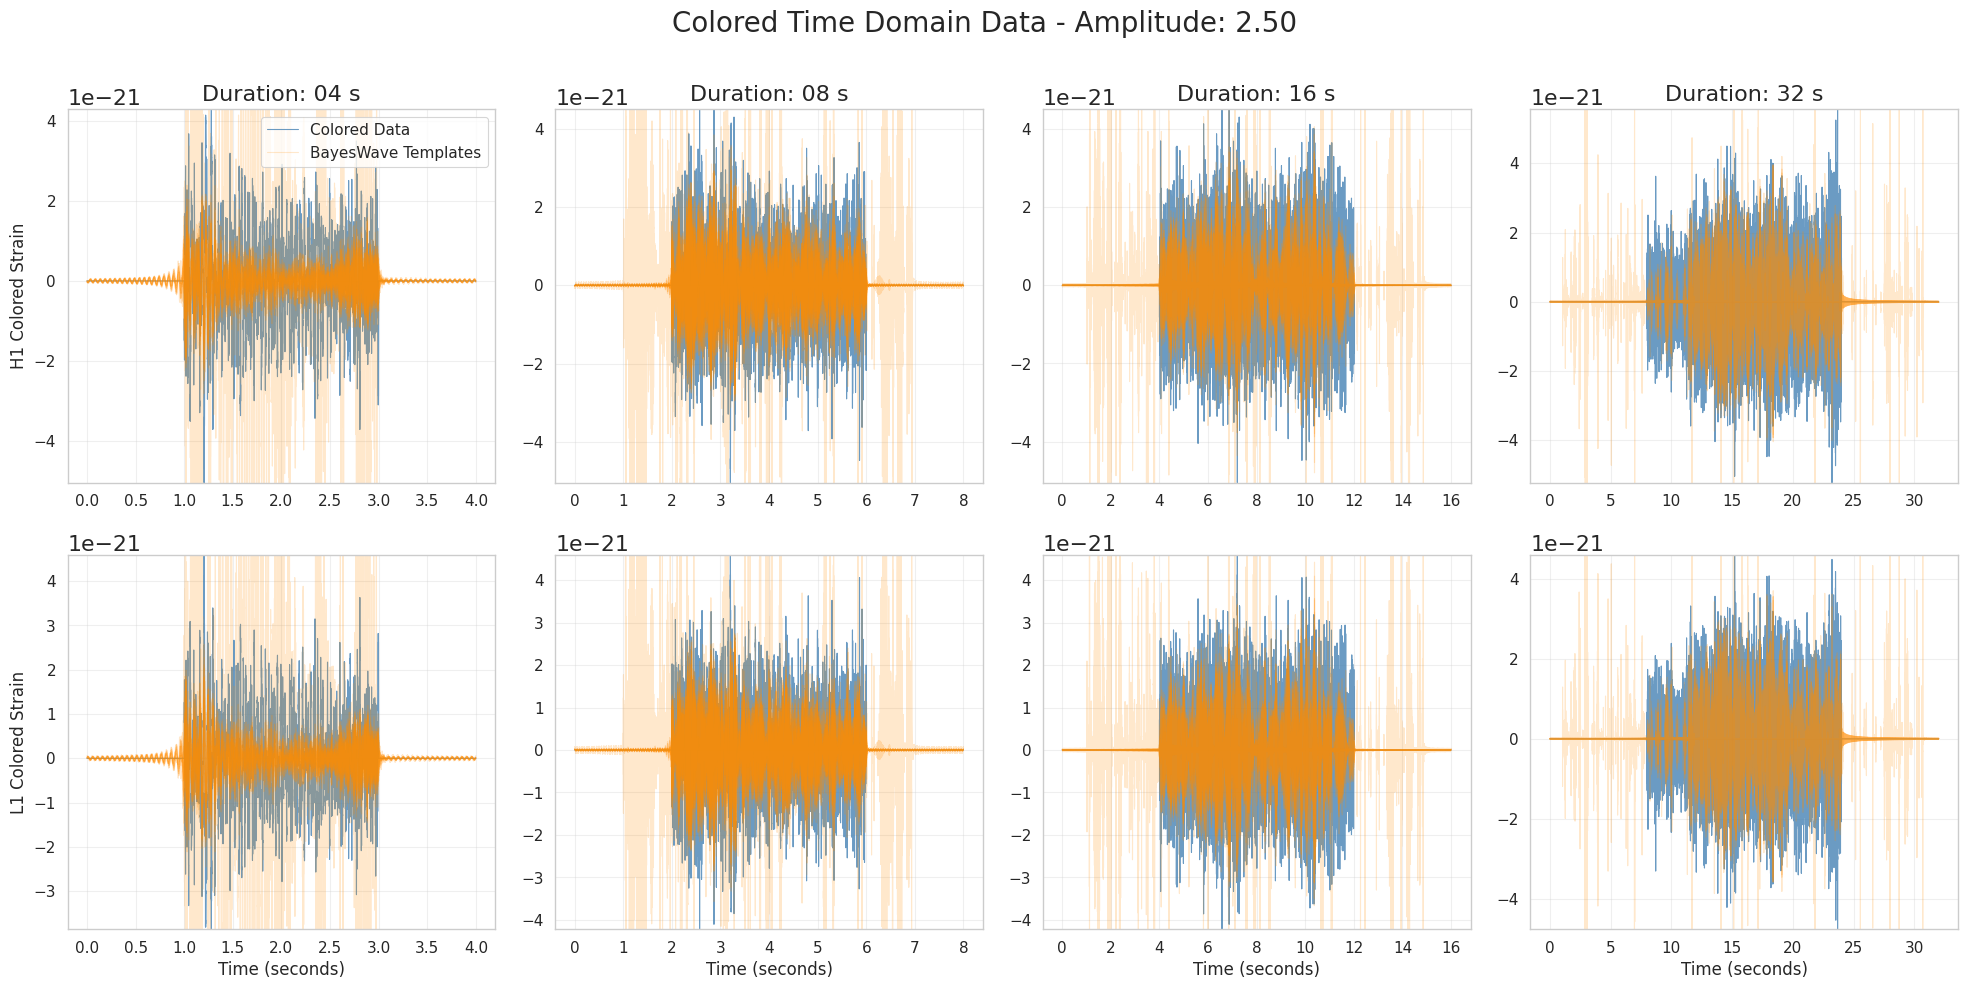

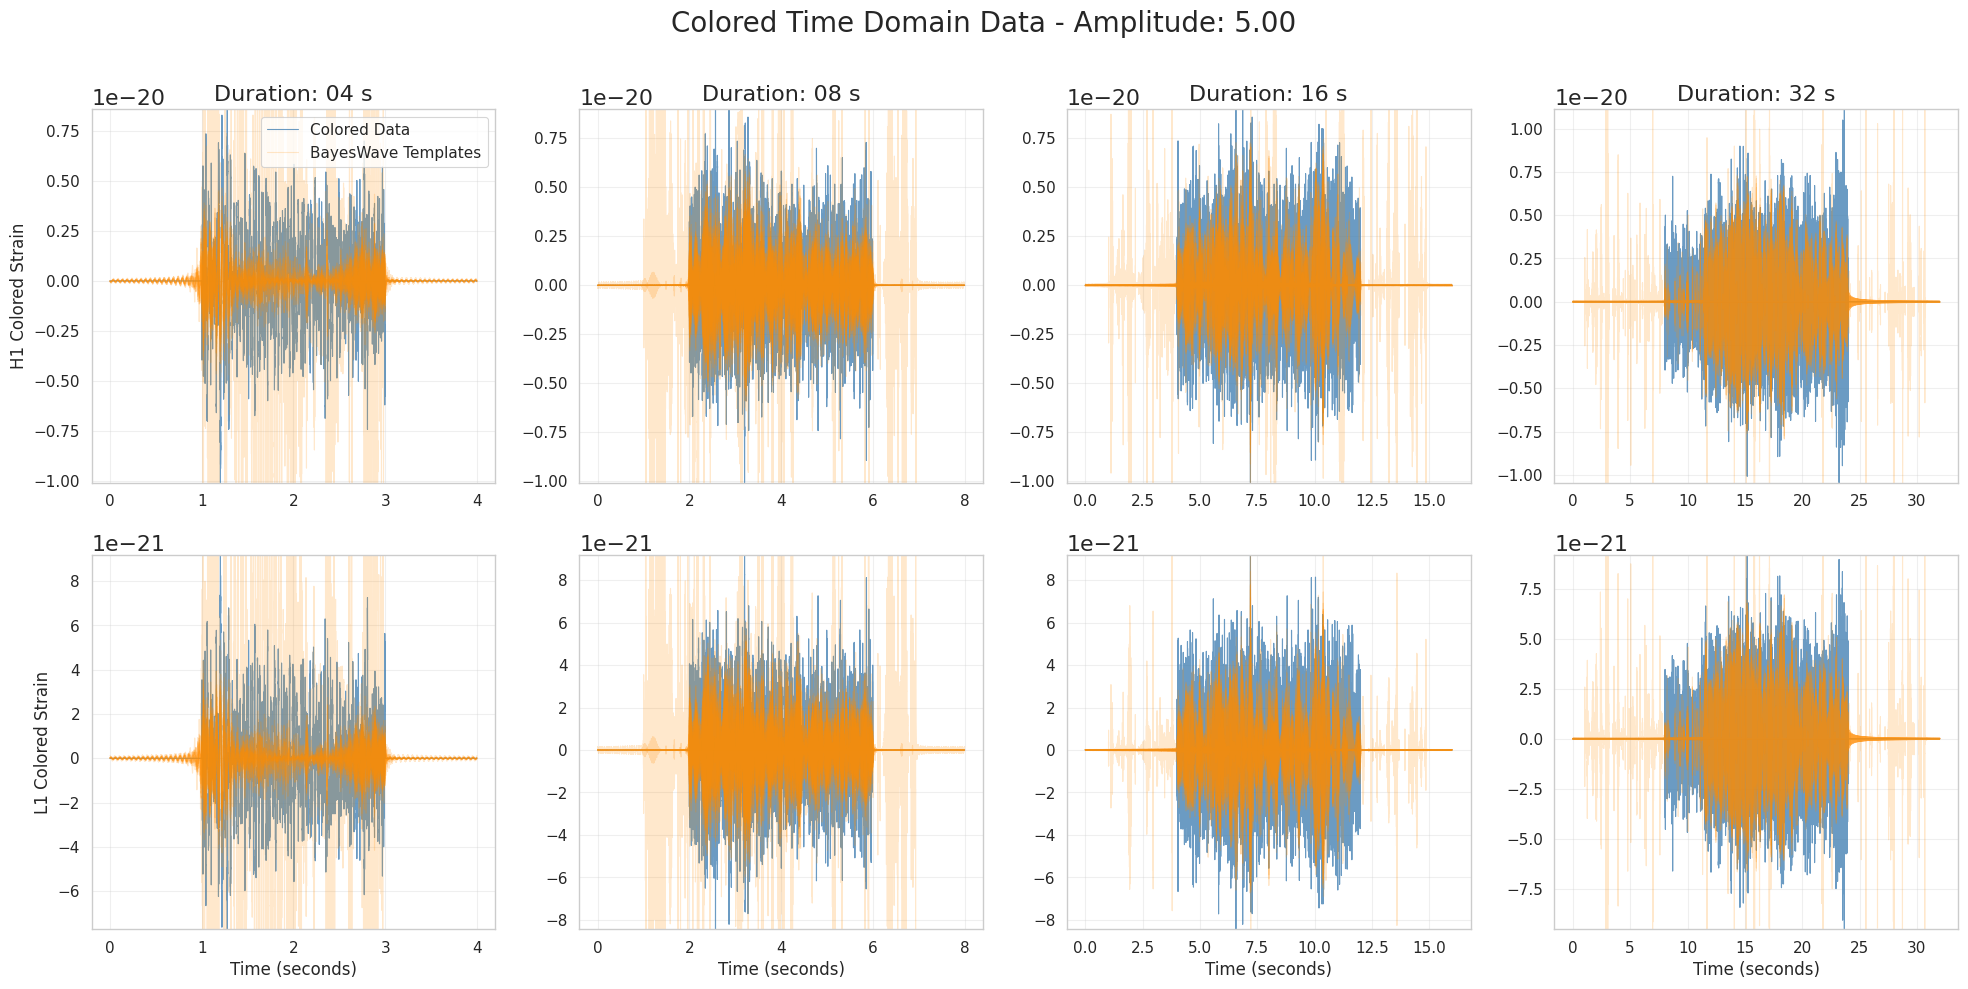

In [ ]:
# Plot colored data: BayesWave reconstruction vs real strain
for amp in amplitudes:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    for col_idx, dur in enumerate(durations):
        exp_dir = base_path / f'dur_{dur}_amp_{amp}'
        data_dir = exp_dir / 'bayeswave_output_0' / 'data'
        template_dir = exp_dir / 'bayeswave_output_0' / 'templates'
        
        # Load colored data
        h1_colored = load_time_domain_data(data_dir / 'colored_time_domain_data_H1.dat')
        l1_colored = load_time_domain_data(data_dir / 'colored_time_domain_data_L1.dat')
        
        # Plot H1
        ax_h1 = axes[0, col_idx]
        ax_h1.plot(h1_colored[:, 0], h1_colored[:, 1], '-', 
                   color='steelblue', linewidth=0.8, label='Colored Data', alpha=0.8)

        
        # Plot all 11 colored BayesWave templates with low alpha
        for i in range(11):
            template_file = template_dir / f'all_colored_time_domain_template_H1_{i}.dat'
            if template_file.exists():
                h1_template = load_time_domain_data(template_file)
                
                label = 'BayesWave Templates' if i == 0 else None
                ax_h1.plot(h1_template[:, 0], h1_template[:, 1], '-', 
                           color='darkorange', linewidth=0.8, label=label, alpha=0.2)
        
        ax_h1.set_title(f'Duration: {dur.replace("s", " s")}', fontsize=16)
        if col_idx == 0:
            ax_h1.set_ylabel('H1 Colored Strain', fontsize=12)
            ax_h1.legend(loc='upper right', fontsize=11)
        ax_h1.grid(True, alpha=0.3)
        ax_h1.tick_params(axis='both', which='major', labelsize=11)
        ax_h1.set_ylim(h1_colored[:, 1].min()*(1.0+1e-20), h1_colored[:, 1].max()*(1.0+1e-20))
        
        # Plot L1
        ax_l1 = axes[1, col_idx]
        ax_l1.plot(l1_colored[:, 0], l1_colored[:, 1], '-', 
                   color='steelblue', linewidth=0.8, label='Colored Data', alpha=0.8)
        
        # Plot all 11 colored BayesWave templates with low alpha
        for i in range(11):
            template_file = template_dir / f'all_colored_time_domain_template_L1_{i}.dat'
            if template_file.exists():
                l1_template = load_time_domain_data(template_file)
                
                label = 'BayesWave Templates' if i == 0 else None
                ax_l1.plot(l1_template[:, 0], l1_template[:, 1], '-', 
                           color='darkorange', linewidth=0.8, label=label, alpha=0.2)
        
        if col_idx == 0:
            ax_l1.set_ylabel('L1 Colored Strain', fontsize=12)
        ax_l1.set_xlabel('Time (seconds)', fontsize=12)
        ax_l1.grid(True, alpha=0.3)
        ax_l1.tick_params(axis='both', which='major', labelsize=11)
        ax_l1.set_ylim(l1_colored[:, 1].min()*(1.0+1e-20), l1_colored[:, 1].max()*(1.0+1e-20))
    
    fig.suptitle(f'Colored Time Domain Data - Amplitude: {amp}', fontsize=20, y=0.995)
    plt.tight_layout()
    plt.show()